[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pablolob/calc_dif_equations_LAB/blob/main/02_Quimiotaxis_Celular.ipynb)


# 🦠 LAB 2: Quimiotaxis — ¿Hacia Dónde Huele el Peligro?

Un neutrófilo patrulla el torrente sanguíneo buscando una bacteria invasora. No tiene ojos: navega **siguiendo el gradiente de una señal química** que la bacteria libera al entorno, un proceso conocido como **quimiotaxis**.

**El problema matemático**: El neutrófilo puede medir cómo varía la concentración química si se mueve en una dirección concreta (Norte, Noreste, Este...). ¿Cuál es la dirección que maximiza ese cambio?

La concentración sigue el campo escalar:

$$C(x,y) = e^{-0.2(x^2 + y^2)}$$

La bacteria está en el origen $(0,0)$. El neutrófilo parte de $(-3, -3)$. Tu misión: encontrar matemáticamente la dirección óptima.

---

In [ ]:
# !!! ESTA CELDA ES SOLO DE CONFIGURACIÓN.
# Este bloque contiene código auxiliar; ejecútalo para poder visualizar los resultados más adelante.
import numpy as np
import matplotlib.pyplot as plt

def dibujar_quimiotaxis(x_celula, y_celula, dCdx, dCdy, D_por_angulo):
    """Mapa de concentración + diagrama polar de la derivada direccional."""
    thetas = np.linspace(0, 2 * np.pi, 360)

    fig = plt.figure(figsize=(13, 6))

    # --- Panel izquierdo: mapa de concentración ---
    ax1 = fig.add_subplot(121)
    X, Y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
    Z = np.exp(-0.2 * (X**2 + Y**2))
    ax1.contourf(X, Y, Z, levels=20, cmap='Greens')
    ax1.scatter(0, 0, color='red', s=200, zorder=5, label='Bacteria 🦠')
    ax1.scatter(x_celula, y_celula, color='deepskyblue', s=200, zorder=5, label='Neutrófilo 🛡️')
    if dCdx is not None and dCdy is not None:
        mag = np.sqrt(dCdx**2 + dCdy**2)
        if mag > 0:
            ax1.quiver(x_celula, y_celula, dCdx / mag, dCdy / mag,
                       scale=4, color='yellow', width=0.015, zorder=6,
                       label='Dirección óptima')
    ax1.set_xlim(-5, 5); ax1.set_ylim(-5, 5)
    ax1.set_aspect('equal')
    ax1.set_title('Mapa de Concentración Química')
    ax1.set_xlabel('x'); ax1.set_ylabel('y')
    ax1.legend(loc='upper right')

    # --- Panel derecho: diagrama polar de la derivada direccional ---
    ax2 = fig.add_subplot(122, projection='polar')
    if D_por_angulo is not None:
        # Lóbulo positivo (moverse HACIA la bacteria → concentración sube)
        D_pos = np.clip(D_por_angulo, 0, None)
        # Lóbulo negativo (moverse ALEJÁNDOSE → concentración baja), girado 180°
        D_neg = np.clip(-D_por_angulo, 0, None)

        ax2.plot(thetas, D_pos, color='orange', lw=2, label='Concentración sube ↑')
        ax2.fill(thetas, D_pos, color='orange', alpha=0.25)
        ax2.plot(thetas, D_neg, color='steelblue', lw=2, label='Concentración baja ↓')
        ax2.fill(thetas, D_neg, color='steelblue', alpha=0.15)

        idx_max = int(np.argmax(D_pos))
        theta_max = thetas[idx_max]
        val_max   = D_pos[idx_max]
        ax2.plot(theta_max, val_max, 'r*', markersize=15,
                 label=f'Óptimo: θ = {np.degrees(theta_max):.1f}°\n'
                       f'$D_{{\\theta}}C$ = {val_max:.4f} conc/dist')

        # Etiqueta de escala en el eje radial
        ax2.yaxis.set_tick_params(labelsize=7)
        ax2.set_rlabel_position(22.5)

        ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

    ax2.set_title('Derivada Direccional $D_\\theta C$\n'
                  '(radio = cambio de concentración por unidad de distancia)',
                  pad=20, fontsize=9)

    plt.tight_layout()
    plt.show()


### 🛠️ ¡TU TURNO!

Antes se ha utilizado el gradiente como la mejor dirección para llegar al óptimo. Sin embargo, estaría bien encontrar la dirección de manera empírica.  
Hay que encontrar la mejor **derivada direccional**: dada una dirección unitaria $\mathbf{u} = (\cos\theta,\, \sin\theta)$, la variación de $C$ al moverse en esa dirección es:

$$D_\mathbf{u}\, C(x,y) = \nabla C \cdot \mathbf{u} = \frac{\partial C}{\partial x}\cos\theta + \frac{\partial C}{\partial y}\sin\theta$$

**Tu tarea:**

1. Aplica la regla de la cadena para calcular $\dfrac{\partial C}{\partial x}$ y $\dfrac{\partial C}{\partial y}$ siendo $C = e^{-0.2(x^2+y^2)}$.
2. Evalúa esas derivadas en la posición del neutrófilo $(-3,\,-3)$.
3. Calcula $D_\theta C$ para todos los ángulos del array `thetas` y, con el diagrama polar, identifica cuál es el máximo.

*Pista: empieza derivando $e^u$ respecto a $u$ y luego aplica la regla de la cadena con $u = -0.2(x^2+y^2)$.*

C:\Users\pablo\AppData\Local\Temp\ipykernel_54520\1411182622.py:61: UserWarning: Glyph 129440 (\N{MICROBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pablo\AppData\Local\Temp\ipykernel_54520\1411182622.py:61: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


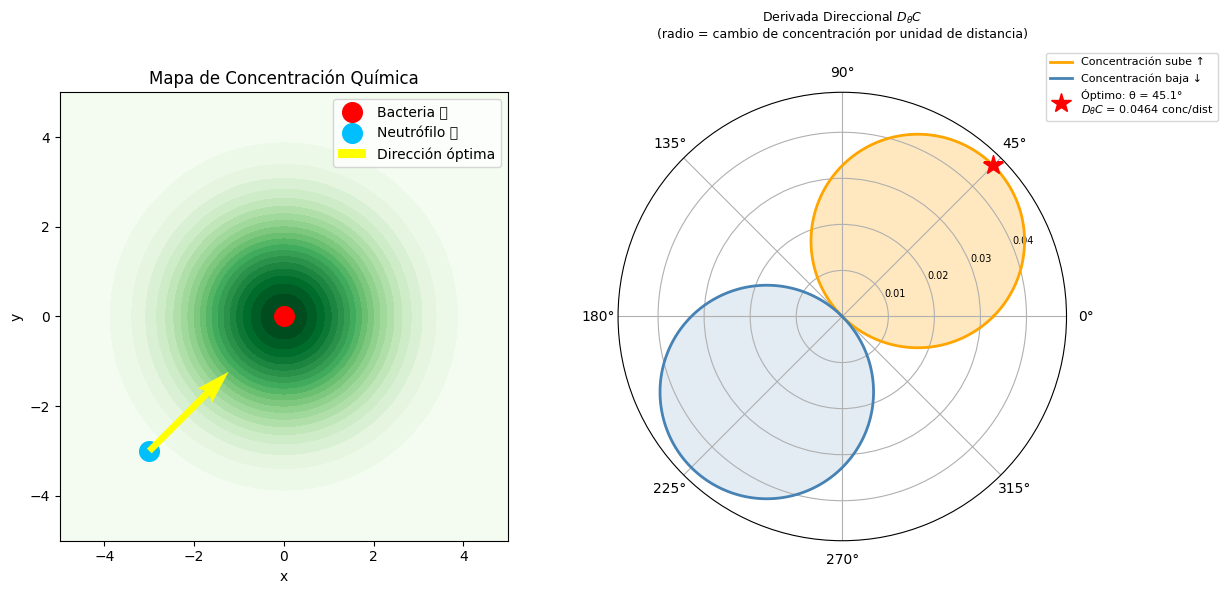

In [ ]:
x_celula = -3.0
y_celula = -3.0

C = np.exp(-0.2 * (x_celula**2 + y_celula**2))  # Concentración en la posición actual

# Paso 1: Derivadas parciales de C evaluadas en la posición del neutrófilo
dCdx = None    # <--- ¡Tu turno! Derivada parcial respecto a x
dCdy = None    # <--- ¡Tu turno! Derivada parcial respecto a y

# Paso 2: Derivada direccional para cada ángulo θ ∈ [0, 2π]
thetas = np.linspace(0, 2 * np.pi, 360)
D_por_angulo = None  # <--- ¡Tu turno! Usa dCdx, dCdy y thetas

dibujar_quimiotaxis(x_celula, y_celula, dCdx, dCdy, D_por_angulo)

<details>
<summary><b>¿Atascado? Haz clic aquí para ver la Solución</b></summary>

Derivadas parciales con la regla de la cadena ($u = -0.2(x^2+y^2)$, $C = e^u$):

```python
dCdx = -0.4 * x_celula * C
dCdy = -0.4 * y_celula * C
```

Derivada direccional para todos los ángulos:

```python
D_por_angulo = dCdx * np.cos(thetas) + dCdy * np.sin(thetas)
```
</details>

### 🔍 Experimenta y Reflexiona

Una vez que funcione, observa el diagrama polar y reflexiona:

- **¿En qué ángulo θ aparece el máximo?** ¿Qué dirección geométrica representa eso desde $(-3,-3)$ hacia la bacteria?
- **Cambia la posición** a `x_celula = -2.0, y_celula = 0.0` o a `x_celula = 1.0, y_celula = -4.0`. ¿El diagrama polar siempre apunta hacia el origen?

---

## 📚 Referencias

**Keller, E.F. & Segel, L.A. (1971).** *Model for chemotaxis.* Journal of Theoretical Biology, 30(2), 225–234.  
[→ DOI: 10.1016/0022-5193(71)90050-5](https://doi.org/10.1016/0022-5193(71)90050-5)

**Zigmond, S.H. (1977).** *Ability of polymorphonuclear leukocytes to orient in gradients of chemotactic factors.* Journal of Cell Biology, 75(2), 606–616.  
[→ DOI: 10.1083/jcb.75.2.606](https://doi.org/10.1083/jcb.75.2.606)

**Lauffenburger, D.A. & Horwitz, A.F. (1996).** *Cell Migration: A Physically Integrated Molecular Process.* Cell, 84(3), 359–369.  
[→ DOI: 10.1016/S0092-8674(00)81280-5](https://doi.org/10.1016/S0092-8674(00)81280-5)

---

## Mis Respuestas

**Pregunta 1.**

*Escribe aquí tu respuesta...*

---

**Pregunta 2.**

*Escribe aquí tu respuesta...*

---

**Pregunta 3.**

*Escribe aquí tu respuesta...*
